In [3]:
from typing import Callable, Any
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from joblib import Parallel, delayed

modern_palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3",
                  "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"]

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette=modern_palette,
    font="sans-serif",
)

ModuleNotFoundError: No module named 'numpy'

# Generowanie zbiorów

In [ ]:
def uniform_dataset(n_samples: int = 100) -> tuple[np.ndarray, np.ndarray]:
    points = np.random.rand(n_samples, 2) * 100
    return points, np.array([0 for _ in range(n_samples)])

In [ ]:
def groups_dataset(n_samples: int = 256) -> tuple[np.ndarray, np.ndarray]:
    return make_blobs(n_samples=n_samples, centers=9, n_features=2, cluster_std=25, center_box=(-500, 500))

In [ ]:
def gaussian_dataset(n_samples: int = 256) -> tuple[np.ndarray, np.ndarray]:
    return make_blobs(n_samples=n_samples, centers=4, n_features=2, cluster_std=[40, 70, 30, 100],
                      center_box=(-100, 100))

In [ ]:
def plot_groups(points: np.ndarray, labels: np.ndarray):
    plt.figure(figsize=(5, 5))
    plt.scatter(points[:, 0], points[:, 1], c=labels, s=15, alpha=0.9, cmap='Set1')
    plt.show()

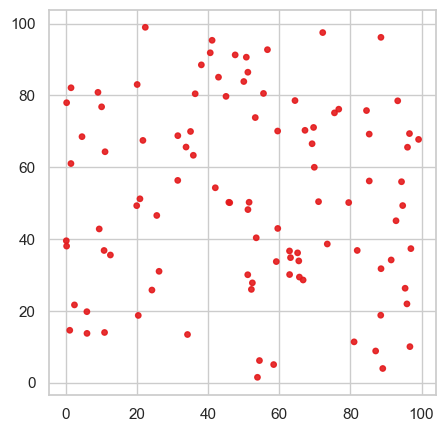

In [ ]:
points, labels = uniform_dataset()
plot_groups(points, labels)

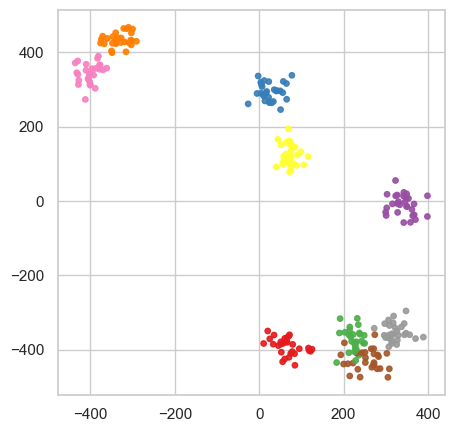

In [ ]:
points, labels = groups_dataset()
plot_groups(points, labels)

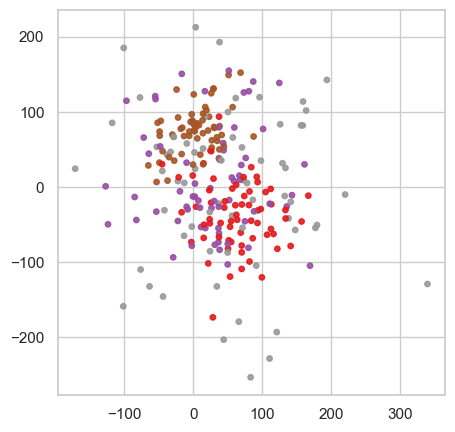

In [ ]:
points, labels = gaussian_dataset()
plot_groups(points, labels)

# Rozważane funkcje temperatury

*   $T_i$ – aktualna temperatura (w kodzie argument `t`)
*   $T_{i+1}$ – nowa temperatura zwracana przez funkcję
*   $T_0$ – temperatura początkowa (w kodzie `t0`)
*   $k$ – numer aktualnej epoki/iteracji (w kodzie argument `k`)

**Rozważane wzory funkcji temperatury:**

*   **Wykładnicza (`exp`)**:
    $T_{i+1} = T_i \cdot \text{decay\_factor}$

*   **Liniowa (`linear`)**:
    $T_{i+1} = T_i - \alpha$

*   **Kosinusoidalna (`cosine`)**:
    $T_k = T_0 \cdot \frac{1}{2} \left(1 + \cos\left(\frac{\pi k}{\text{max\_epochs}}\right)\right)$

*   **Lundy & Mees (`lundy_and_mees`)**:
    $T_{i+1} = \frac{T_i}{1 + 0.00001 \cdot T_i}$

*   **Logarytmiczna (`log`)**:
    $T_k = \frac{T_0}{1 + \alpha \ln(1 + k)}$
    *(gdzie $\alpha = \frac{\frac{1}{\text{target\_fraction}} - 1}{\ln(1 + \text{max\_epochs})}$)*

In [ ]:
def annealing_schedule_exp(decay_factor: float = 0.9999):
    def schedule(t: float, _: int):
        return t * decay_factor

    return schedule


def annealing_schedule_linear(alpha: float = 0.01):
    def schedule(t: float, _: int):
        return t - alpha 

    return schedule


def annealing_schedule_cosine(t0: float, max_epochs: int):
    def schedule(t: float, k: int):
        return t0 * (1 / 2) * (1 + np.cos((np.pi * k) / max_epochs))
    
    return schedule


def annealing_schedule_lundy_and_mees():
    def schedule(t: float, k: int):
        return t / (1 + 0.00001 * t)
    
    return schedule


def annealing_schedule_log(t0: float, max_epochs: int, target_fraction: float = 0.1):
    alpha = ( (1.0 / target_fraction) - 1.0 ) / np.log(1 + max_epochs)

    def schedule(_: float, k: int):
        return t0 / (1 + alpha * np.log(1 + k))

    return schedule

# Rozważane funkcje przejścia

**Lista operacji sąsiedztwa:**

*   **2-Opt (`tsp_transition_2_opt`)**:
    Polega na wybraniu dwóch indeksów $i, j$ i **odwróceniu** kolejności miast na fragmencie trasy między nimi.
    Punkty: $A = x_{i-1}$, $B = x_i$, $C = x_j$, $D = x_{j+1}$.
    
    Z trasy usuwane są krawędzie $(A, B)$ i $(C, D)$, a w ich miejsce wchodzą $(A, C)$ i $(B, D)$.
    $\Delta y = (||A - C|| + ||B - D||) - (||A - B|| + ||C - D||)$

*   **Zamiana sąsiadów (`tsp_transition_consecutive_swap`)**:
    Polega na prostej **zamianie miejscami** dwóch miast leżących bezpośrednio obok siebie na trasie (indeksy $i$ oraz $j=i+1$).
    Punkty: $A = x_{i-1}$, $B = x_i$, $C = x_j$, $D = x_{j+1}$.
    
    Podobnie jak w 2-opt, zrywamy zewnętrzne połączenia tych miast i przepinamy je na krzyż (odległość między samym $B$ i $C$ się nie zmienia, bo tylko idziemy w odwrotnym kierunku).
    $\Delta y = (||A - C|| + ||B - D||) - (||A - B|| + ||C - D||)$

*   **Zamiana dowolna (`tsp_transition_arbitrary_swap`)**:
    Polega na **zamianie miejscami** dwóch *niesąsiadujących* ze sobą miast na trasie (losowe indeksy $i, j$, gdzie odległość między nimi jest większa niż 1).
    Punkty wokół $i$: $A = x_{i-1}$, $B = x_i$, $C = x_{i+1}$.
    Punkty wokół $j$: $D = x_{j-1}$, $E = x_j$, $F = x_{j+1}$.
    
    Zrywamy 4 krawędzie przylegające do obu miast i tworzymy 4 nowe.
    $\Delta y = (||A - E|| + ||E - C|| + ||D - B|| + ||B - F||) - (||A - B|| + ||B - C|| + ||D - E|| + ||E - F||)$

In [ ]:
def tsp_transition_2_opt(x: np.ndarray) -> tuple[float, Callable[[np.ndarray], Any]]:
    n = len(x)
    
    while True:
        i, j = np.sort(np.random.choice(n, 2, replace=False))

        if j - i < n - 1:
            break

    A = x[i - 1]
    B = x[i]
    C = x[j]
    D = x[(j + 1) % n]

    old_dist = np.linalg.norm(A - B) + np.linalg.norm(C - D)
    new_dist = np.linalg.norm(A - C) + np.linalg.norm(B - D)
    delta_y = float(new_dist - old_dist)

    def apply():
        x[i:j + 1] = x[i:j + 1][::-1]

    return delta_y, apply


def tsp_transition_consecutive_swap(x: np.ndarray) -> tuple[float, Callable[[np.ndarray], Any]]:
    n = len(x)
    i = np.random.choice(n)
    j = (i + 1) % n

    A = x[i - 1]
    B = x[i]
    C = x[j]
    D = x[(j + 1) % n]

    old_dist = np.linalg.norm(A - B) + np.linalg.norm(C - D)
    new_dist = np.linalg.norm(A - C) + np.linalg.norm(B - D)
    delta_y = float(new_dist - old_dist)

    def apply():
        x[[i, j]] = x[[j, i]]

    return delta_y, apply


def tsp_transition_arbitrary_swap(x: np.ndarray) -> tuple[float, Callable[[np.ndarray], Any]]:
    n = len(x)

    while True:
        i, j = np.sort(np.random.choice(n, 2, replace=False))
        is_adjacent = (j - i == 1) or (i == 0 and j == n - 1)

        if not is_adjacent:
            break

    A = x[i - 1]
    B = x[i]
    C = x[(i + 1) % n]

    D = x[j - 1]
    E = x[j]
    F = x[(j + 1) % n]

    old_dist = (np.linalg.norm(A - B) + np.linalg.norm(B - C) + 
                np.linalg.norm(D - E) + np.linalg.norm(E - F))
                
    new_dist = (np.linalg.norm(A - E) + np.linalg.norm(E - C) + 
                np.linalg.norm(D - B) + np.linalg.norm(B - F))
                
    delta_y = float(new_dist - old_dist)

    def apply():
        x[[i, j]] = x[[j, i]]

    return delta_y, apply

In [ ]:
def tsp_energy_fn(x: np.ndarray) -> float:
    closed_loop = np.vstack([x, x[0]])
    return float(np.sum(np.linalg.norm(np.diff(closed_loop, axis=0), axis=1)))

Do ustalenia początkowej temperatury wykorzystujemy średnią z pogarszających zmian wartości funkcji celu ($\overline{\Delta y^+}$) oraz zakładane początkowe prawdopodobieństwo ich akceptacji ($P_0$), stosując wzór:

$$
T_0 = -\frac{\overline{\Delta y^+}}{\ln(P_0)}
$$

In [ ]:
def estimate_initial_temperature(
    x: np.ndarray,
    delta_fn: Callable[[np.ndarray], float],
    initial_acceptance = 0.8,
    iterations = 1000
) -> float:
    positive_energy_changes = 0
    no_positive_energy_changes = 0

    for _ in range(iterations):
        delta_y = delta_fn(x)

        if delta_y > 0:
            no_positive_energy_changes += 1
            positive_energy_changes += delta_y

    positive_energy_changes /= no_positive_energy_changes
    t = -positive_energy_changes / np.log(initial_acceptance)

    return t


def tsp(
        x: np.ndarray,
        max_epochs: int,
        transition_fn: Callable[[np.ndarray], tuple[float, Callable[[np.ndarray], Any]]],
        energy_fn: Callable[[np.ndarray], float],
        annealing_schedule_factory: Callable[[float, int], Callable[[float, int], float]],
        epoch_size = 50,
        temperature_estimation_iterations=1000,
):
    t = estimate_initial_temperature(
        x, 
        lambda x: transition_fn(x)[0], 
        iterations=temperature_estimation_iterations
    )

    annealing_schedule = annealing_schedule_factory(t, max_epochs)
    y = energy_fn(x)
    x_best, y_best = x.copy(), y

    energy_log = [y]
    temp_log = [t]

    for epoch in range(max_epochs):
        for _ in range(epoch_size):
            delta_y, apply = transition_fn(x)

            if delta_y <= 0 or np.random.uniform() < np.exp(-delta_y / t):
                apply()
                y += delta_y

                if y < y_best:
                    x_best, y_best = x.copy(), y

        energy_log.append(y)
        temp_log.append(t)

        t = annealing_schedule(t, epoch)
        if t < 1e-4:
            break

    return x_best, y_best, energy_log, temp_log

## Przedstawienie rozwiązania problemu TSP dla rozważanych zbiorów punktów

In [ ]:
def plot_all_tsp_solutions(all_solutions: list[tuple[str, list[tuple[int, np.ndarray, list, list]]]]):
    n_datasets = len(all_solutions)

    fig = plt.figure(figsize=(45, 15), dpi=150, layout="constrained")
    subfigs = fig.subfigures(nrows=1, ncols=n_datasets, wspace=0.05)

    for col, (dataset, solutions) in enumerate(all_solutions):
        n_sol = len(solutions)
        subfig = subfigs[col]

        subfig.suptitle(f'Dataset: {dataset}', fontsize=16, fontweight='bold')
        
        axs = subfig.subplots(nrows=n_sol, ncols=2)

        for i in range(n_sol):
            param, solution, temperature_log, energy_log = solutions[i]

            ax_energy = axs[i, 0]
            ax_sol = axs[i, 1]

            ax_energy.plot(energy_log, color='blue', alpha=0.8, label='Energy')
            ax_energy.set_title('Energy and Temperature over Time')
            ax_energy.set_xlabel('Epoch')
            ax_energy.set_ylabel('Energy', color='blue')
            ax_energy.tick_params(axis='y', labelcolor='blue')
            ax_energy.grid(True, color='silver', linestyle='--', linewidth=0.7, alpha=0.7)

            ax_energy.annotate(
                f'Points: {param}',
                xy=(-0.25, 0.5),
                xycoords='axes fraction',
                fontsize=14,
                rotation=90,
                va='center',
                ha='center',
                fontweight='bold'
            )

            ax_temp = ax_energy.twinx()
            ax_temp.plot(temperature_log, color='red', alpha=0.8, label='Temperature', zorder=5)
            ax_temp.set_ylabel('Temperature', color='red')
            ax_temp.tick_params(axis='y', labelcolor='red')
            
            closed_loop = np.vstack([solution, solution[0]])
            x_coords = closed_loop[:, 0]
            y_coords = closed_loop[:, 1]

            ax_sol.plot(x_coords, y_coords, marker='o', markersize=3, color='green', linestyle='-', alpha=0.7)
            ax_sol.set_title('Solution')
            ax_sol.set_xlabel('X')
            ax_sol.set_ylabel('Y')
            ax_sol.set_box_aspect(1) 
            
            ax_sol.grid(True, color='gainsboro', linestyle=':', linewidth=1.0, alpha=0.8)

    plt.show()

In [ ]:
def generate_solutions():
    max_epochs = 10_000
    all_dataset_solutions = []
    decay = 0.9993

    def exp_schedule_factory(t0, max_epochs):
        return annealing_schedule_exp(decay)

    for (dataset_name, dataset_gen, params) in [
        (
            "Uniform",
            uniform_dataset,
            [50, 100, 500]
        ),
        (
            "Gaussian",
            gaussian_dataset,
            [50, 100, 500]
        ),
        (
            "Groups",
            groups_dataset,
            [50, 100, 500]
        )
    ]:
        solutions = []

        for n in params:
            cities, _ = dataset_gen(n)
            transition = tsp_transition_2_opt

            solution, _, energy_log, temperature_log = tsp(
                cities,
                max_epochs=max_epochs,
                transition_fn=transition,
                energy_fn=tsp_energy_fn,
                annealing_schedule_factory=exp_schedule_factory,
            )

            solutions.append((n, solution, temperature_log, energy_log))

        all_dataset_solutions.append((dataset_name, solutions))

    return all_dataset_solutions

In [ ]:
# NOTE: Uncomment to run
# solutions = generate_solutions()
# plot_all_tsp_solutions(solutions)

![Image description](zad1_poster_datasets.png)

## Analiza wyboru funkcji generującej sąsiednie stany problemu TSP

In [ ]:
def plot_setup_comparison(grid_data: list[list[tuple[str, str, list]]]):
    n_rows = len(grid_data)
    n_cols = len(grid_data[0])

    fig = plt.figure(figsize=(n_cols * 12, n_rows * 12), dpi=150, layout="constrained")
    subfigs = fig.subfigures(nrows=n_rows, ncols=n_cols, wspace=0.05, hspace=0.05)

    for r in range(n_rows):
        for c in range(n_cols):
            sched_name, trans_name, solutions = grid_data[r][c]
            n_sol = len(solutions)

            if n_rows == 1 and n_cols == 1:
                subfig = subfigs
            elif n_rows == 1:
                subfig = subfigs[c]
            elif n_cols == 1:
                subfig = subfigs[r]
            else:
                subfig = subfigs[r, c]

            subfig.suptitle(f'Transition: {trans_name}', fontsize=20, fontweight='bold')
            subfig.supylabel(f'Schedule: {sched_name}', fontsize=20, fontweight='bold')

            axs = subfig.subplots(nrows=n_sol, ncols=2)

            for i in range(n_sol):
                n_points, solution, temperature_log, energy_log = solutions[i]

                ax_energy = axs[i, 0]
                ax_sol = axs[i, 1]

                ax_energy.plot(energy_log, color='blue', alpha=0.8, label='Energy')
                ax_energy.set_title('Energy and Temperature over Time')
                ax_energy.set_xlabel('Epoch') # or Iteration
                ax_energy.set_ylabel('Energy', color='blue')
                ax_energy.tick_params(axis='y', labelcolor='blue')
                
                ax_energy.grid(True, color='silver', linestyle='--', linewidth=0.7, alpha=0.7)

                ax_energy.annotate(
                    f'n_points: {n_points}',
                    xy=(-0.35, 0.5), 
                    xycoords='axes fraction',
                    fontsize=16,
                    rotation=90,
                    va='center',
                    ha='center',
                    fontweight='bold'
                )

                ax_temp = ax_energy.twinx()
                ax_temp.plot(temperature_log, color='red', alpha=0.8, label='Temperature', zorder=5)
                ax_temp.set_ylabel('Temperature', color='red')
                ax_temp.tick_params(axis='y', labelcolor='red')

                closed_loop = np.vstack([solution, solution[0]])
                x_coords = closed_loop[:, 0]
                y_coords = closed_loop[:, 1]

                ax_sol.plot(x_coords, y_coords, marker='o', markersize=3, color='green', linestyle='-', alpha=0.7)
                ax_sol.set_title('Solution')
                ax_sol.set_xlabel('X')
                ax_sol.set_ylabel('Y')
                
                ax_sol.set_box_aspect(1)
                ax_sol.grid(True, color='gainsboro', linestyle=':', linewidth=1.0, alpha=0.8)

    plt.show()

In [ ]:
def exp_factory(t0, max_epochs):
    return annealing_schedule_exp(0.9993)


def log_factory(t0, max_epochs):
    return annealing_schedule_log(t0, max_epochs)


def linear_factory(t0, max_epochs):
    return annealing_schedule_linear(alpha=0.1)


def cosine_factory(t0, max_epochs):
    return annealing_schedule_cosine(t0, max_epochs)


def lundy_and_mees_factory(t0, max_epochs):
    return annealing_schedule_lundy_and_mees()


def _run_tsp_task(sched_name, sched_factory, trans_name, trans_func, n, cities, max_epochs):
    solution, _, energy_log, temperature_log = tsp(
        cities, 
        max_epochs=max_epochs,
        transition_fn=trans_func,
        energy_fn=tsp_energy_fn,
        annealing_schedule_factory=sched_factory,
    )

    return (sched_name, trans_name, n, solution, temperature_log, energy_log)


def benchmark_transition_functions():
    max_epochs = 10_000

    dataset_50 = uniform_dataset(50)[0]
    dataset_100 = uniform_dataset(100)[0]
    dataset_500 = uniform_dataset(500)[0]

    cities_map = {
        50: dataset_50,
        100: dataset_100,
        500: dataset_500
    }

    transitions = [
        ("Consecutive Swap", tsp_transition_consecutive_swap),
        ("Arbitrary Swap", tsp_transition_arbitrary_swap),
        ("2-OPT", tsp_transition_2_opt)
    ]

    schedules = [
        ("Exp", exp_factory),
        ("Cosine", cosine_factory),
        ("Lundy and Mees", lundy_and_mees_factory),
        ("Log", log_factory),
        ("Linear", linear_factory),
    ]

    results = Parallel(n_jobs=-1)(
        delayed(_run_tsp_task)(
            sched_name, sched_factory, trans_name, trans_func, n, cities_map[n].copy(), max_epochs
        )
        for sched_name, sched_factory in schedules
        for trans_name, trans_func in transitions
        for n in [50, 100, 500]
    )

    grid_data = []
    idx = 0
    
    for sched_name, _ in schedules:
        row_data = []
        for trans_name, _ in transitions:
            solutions = []
            for _ in [50, 100, 500]:
                _, _, res_n, solution, temp_log, energy_log = results[idx]
                solutions.append((res_n, solution, temp_log, energy_log))
                idx += 1

            row_data.append((sched_name, trans_name, solutions))
        grid_data.append(row_data)

    return grid_data

In [ ]:
# NOTE: Uncomment to run
# config_bench = benchmark_transition_functions()
# plot_setup_comparison(config_bench)

![Image description](zad1_poster_methods_comparison.png)